In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/online_retail_clean.csv", parse_dates=["InvoiceDate"])
print(df.shape)
df.head()

(797885, 10)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancellation,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,False,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,False,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False,30.0


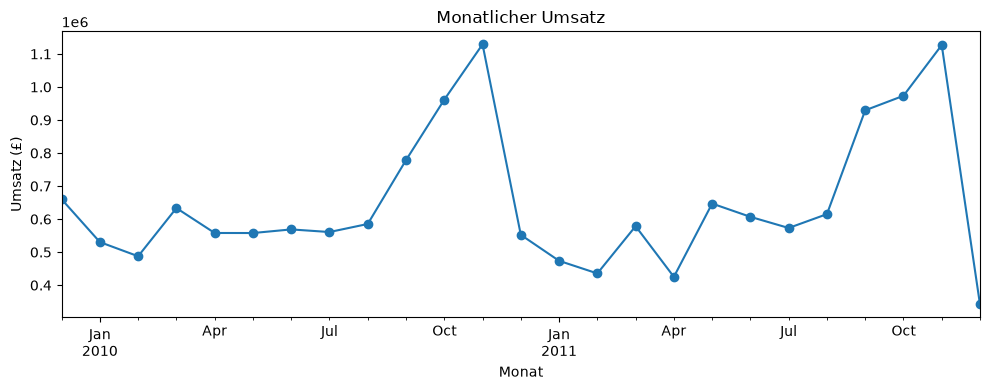

In [2]:
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")
monatsumsatz = df.groupby("InvoiceMonth")["Revenue"].sum()

monatsumsatz.plot(kind="line", figsize=(10, 4), marker="o", title="Monatlicher Umsatz")
plt.ylabel("Umsatz (£)")
plt.xlabel("Monat")
plt.tight_layout()
plt.show()

Country
United Kingdom    1.348251e+07
EIRE              5.735098e+05
Netherlands       5.483307e+05
Germany           4.119592e+05
France            3.200463e+05
Australia         1.664444e+05
Switzerland       9.877941e+04
Spain             9.101344e+04
Sweden            8.742152e+04
Denmark           6.445959e+04
Name: Revenue, dtype: float64


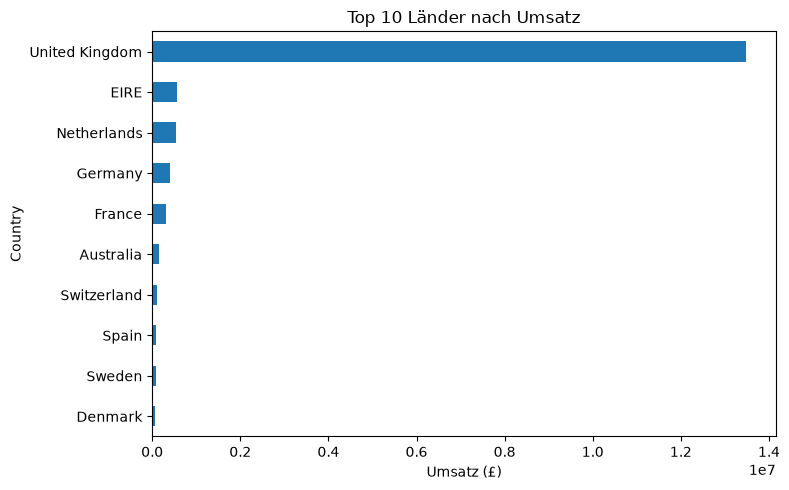

In [3]:
umsatz_nach_land = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)
print(umsatz_nach_land)

umsatz_nach_land.plot(kind="barh", figsize=(8, 5), title="Top 10 Länder nach Umsatz")
plt.xlabel("Umsatz (£)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [4]:
umsatz_nach_produkt = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
print(umsatz_nach_produkt)

Description
REGENCY CAKESTAND 3 TIER              261110.95
WHITE HANGING HEART T-LIGHT HOLDER    237678.61
JUMBO BAG RED RETROSPOT               132180.02
ASSORTED COLOUR BIRD ORNAMENT         123631.87
POSTAGE                               110338.51
PARTY BUNTING                         102089.38
PAPER CHAIN KIT 50'S CHRISTMAS         75388.48
CHILLI LIGHTS                          68453.50
JUMBO BAG STRAWBERRY                   63615.53
BLACK RECORD COVER FRAME               63009.83
Name: Revenue, dtype: float64


In [5]:
print("Erste Transaktion:", df["InvoiceDate"].min())
print("Letzte Transaktion:", df["InvoiceDate"].max())

Erste Transaktion: 2009-12-01 07:45:00
Letzte Transaktion: 2011-12-09 12:50:00


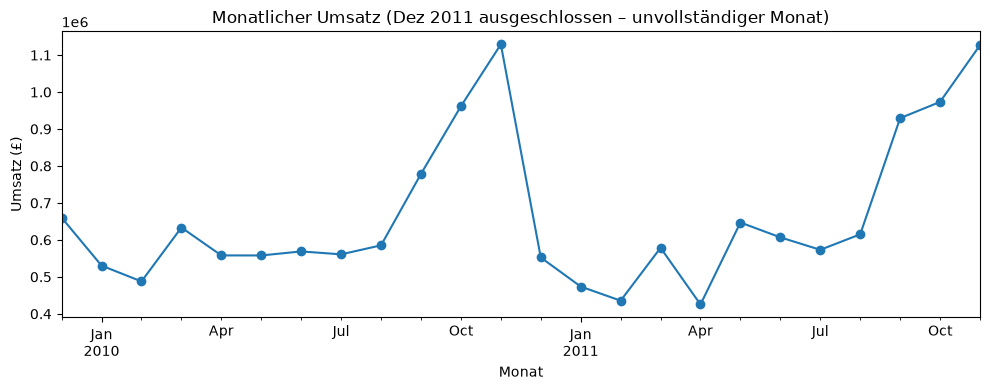

In [6]:
# Unvollständigen letzten Monat (Dez 2011, nur bis zum 9.) aus dem Trend ausschließen
monatsumsatz_vollstaendig = monatsumsatz[:-1]

monatsumsatz_vollstaendig.plot(kind="line", figsize=(10, 4), marker="o",
                                title="Monatlicher Umsatz (Dez 2011 ausgeschlossen – unvollständiger Monat)")
plt.ylabel("Umsatz (£)")
plt.xlabel("Monat")
plt.tight_layout()
plt.show()